In [4]:
import pandas as pd
import numpy as np
import requests
from datetime import datetime

# Functions for VN1 Forecasting Competition ----

def read_and_prepare_data(dataset):
    """
    Reads data in wide format and returns it in long format with columns `unique_id`, `ds`, and `y`
    """
    url = get_dataset_url(dataset)
    df_wide = pd.read_csv(url)
    
    # Create unique_id and select relevant columns
    df_wide['unique_id'] = df_wide['Client'].astype(str) + '/' + df_wide['Warehouse'].astype(str) + '/' + df_wide['Product'].astype(str)
    df_wide = df_wide.drop(columns=['Client', 'Warehouse', 'Product'])
    
    # Pivot the data to long format
    df = df_wide.melt(id_vars=['unique_id'], var_name='ds', value_name='y')
    
    # If dataset starts with 'winners', rename column 'y'
    if dataset.startswith('winners'):
        df.rename(columns={'y': dataset}, inplace=True)
    
    return df

def get_train_data(df0, df1):
    """
    Merges training data from phase 0 and phase 1 and removes leading zeros
    """
    df = pd.concat([df0, df1], ignore_index=True).sort_values(by=['unique_id', 'ds'])
    
    # Calculate cumulative sum and filter rows with cumsum > 0
    df['cumsum'] = df.groupby('unique_id')['y'].cumsum()
    df_clean = df[df['cumsum'] > 0].drop(columns=['cumsum'])
    
    return df_clean

def vn1_competition_evaluation(test, forecast, model):
    """
    Computes competition evaluation
    """
    forecast['ds'] = forecast['ds'].astype(str)  # Ensure 'ds' is a string
    
    # Merge forecast with test data
    res = pd.merge(forecast, test, on=['unique_id', 'ds'], how='inner')
    
    # Calculate absolute error and error
    res['abs_err'] = abs(res[model] - res['y'])
    res['err'] = res[model] - res['y']
    
    # Calculate score
    abs_err = res['abs_err'].sum(skipna=True)
    err = res['err'].sum(skipna=True)
    score = (abs_err + abs(err)) / res['y'].sum()
    
    return round(score, 4)

def get_dataset_url(dataset):
    """
    Returns the URL of the given competition dataset
    """
    urls = {
        "phase0_sales": "https://www.datasource.ai/attachments/eyJpZCI6Ijk4NDYxNjE2NmZmZjM0MGRmNmE4MTczOGMyMzI2ZWI2LmNzdiIsInN0b3JhZ2UiOiJzdG9yZSIsIm1ldGFkYXRhIjp7ImZpbGVuYW1lIjoiUGhhc2UgMCAtIFNhbGVzLmNzdiIsInNpemUiOjEwODA0NjU0LCJtaW1lX3R5cGUiOiJ0ZXh0L2NzdiJ9fQ",
        "phase1_sales": "https://www.datasource.ai/attachments/eyJpZCI6ImM2OGQxNGNmNTJkZDQ1MTUyZTg0M2FkMDAyMjVlN2NlLmNzdiIsInN0b3JhZ2UiOiJzdG9yZSIsIm1ldGFkYXRhIjp7ImZpbGVuYW1lIjoiUGhhc2UgMSAtIFNhbGVzLmNzdiIsInNpemUiOjEwMTgzOTYsIm1pbWVfdHlwZSI6InRleHQvY3N2In19",
        "phase2_sales": "https://www.datasource.ai/attachments/eyJpZCI6IjhlNmJmNmU3ZTlhNWQ4NTcyNGVhNTI4YjAwNTk3OWE1LmNzdiIsInN0b3JhZ2UiOiJzdG9yZSIsIm1ldGFkYXRhIjp7ImZpbGVuYW1lIjoiUGhhc2UgMiAtIFNhbGVzLmNzdiIsInNpemUiOjEwMTI0MzcsIm1pbWVfdHlwZSI6InRleHQvY3N2In19",
        "winners1": "https://www.datasource.ai/attachments/eyJpZCI6IjI1NDQxYmMyMTQ3MTA0MjJhMDcyYjllODcwZjEyNmY4LmNzdiIsInN0b3JhZ2UiOiJzdG9yZSIsIm1ldGFkYXRhIjp7ImZpbGVuYW1lIjoicGhhc2UgMiBzdWJtaXNzaW9uIGV4YW1pbmUgc21vb3RoZWQgMjAyNDEwMTcgRklOQUwuY3N2Iiwic2l6ZSI6MTk5MzAzNCwibWltZV90eXBlIjoidGV4dC9jc3YifX0",
        # Add more datasets here if needed
    }
    return urls.get(dataset)

# VN1 Forecasting Competition Solution with nixtlar ----

# Install necessary packages (make sure to install these beforehand)
# !pip install nixtlar
# !pip install pandas
# !pip install requests

from nixtla import NixtlaClient 
nixtla_client = NixtlaClient(
    api_key = 'nixak-4APr9rXDIbqQ56Sh2B7ief7IWmYUW4QO1gYAIJp8OhMCwvV9hzgQecqzm6PISGQmjZdQNg6hpkhY71Vp'
)

#from nixtlar import nixtla_client_forecast, nixtla_client_plot

# Load Data ----
sales0 = read_and_prepare_data("phase0_sales")
sales1 = read_and_prepare_data("phase1_sales")
test_df = read_and_prepare_data("phase2_sales")

# Prepare Training Dataset ----
train_df = get_train_data(sales0, sales1)

# Generate TimeGPT Forecast ----

# Make sure to set up your API key from Nixtla
# nixtla_client_setup(api_key="Your API key here")

fc = nixtla_client.forecast(train_df, h=13, model="timegpt-1-long-horizon")
fc

INFO:nixtla.nixtla_client:Validating inputs...
INFO:nixtla.nixtla_client:Inferred freq: W-MON
INFO:nixtla.nixtla_client:Preprocessing dataframes...
INFO:nixtla.nixtla_client:Querying model metadata...
INFO:nixtla.nixtla_client:Restricting input...
INFO:nixtla.nixtla_client:Calling Forecast Endpoint...


,unique_id,ds,TimeGPT
0,0/1/10705,2024-01-08,2.370566
1,0/1/10705,2024-01-15,2.034246
2,0/1/10705,2024-01-22,2.036740
3,0/1/10705,2024-01-29,2.248169
4,0/1/10705,2024-02-05,2.268629
...,...,...,...
195684,9/82/9950,2024-03-04,0.013589
195685,9/82/9950,2024-03-11,-0.000209
195686,9/82/9950,2024-03-18,-0.004390
195687,9/82/9950,2024-03-25,0.000814


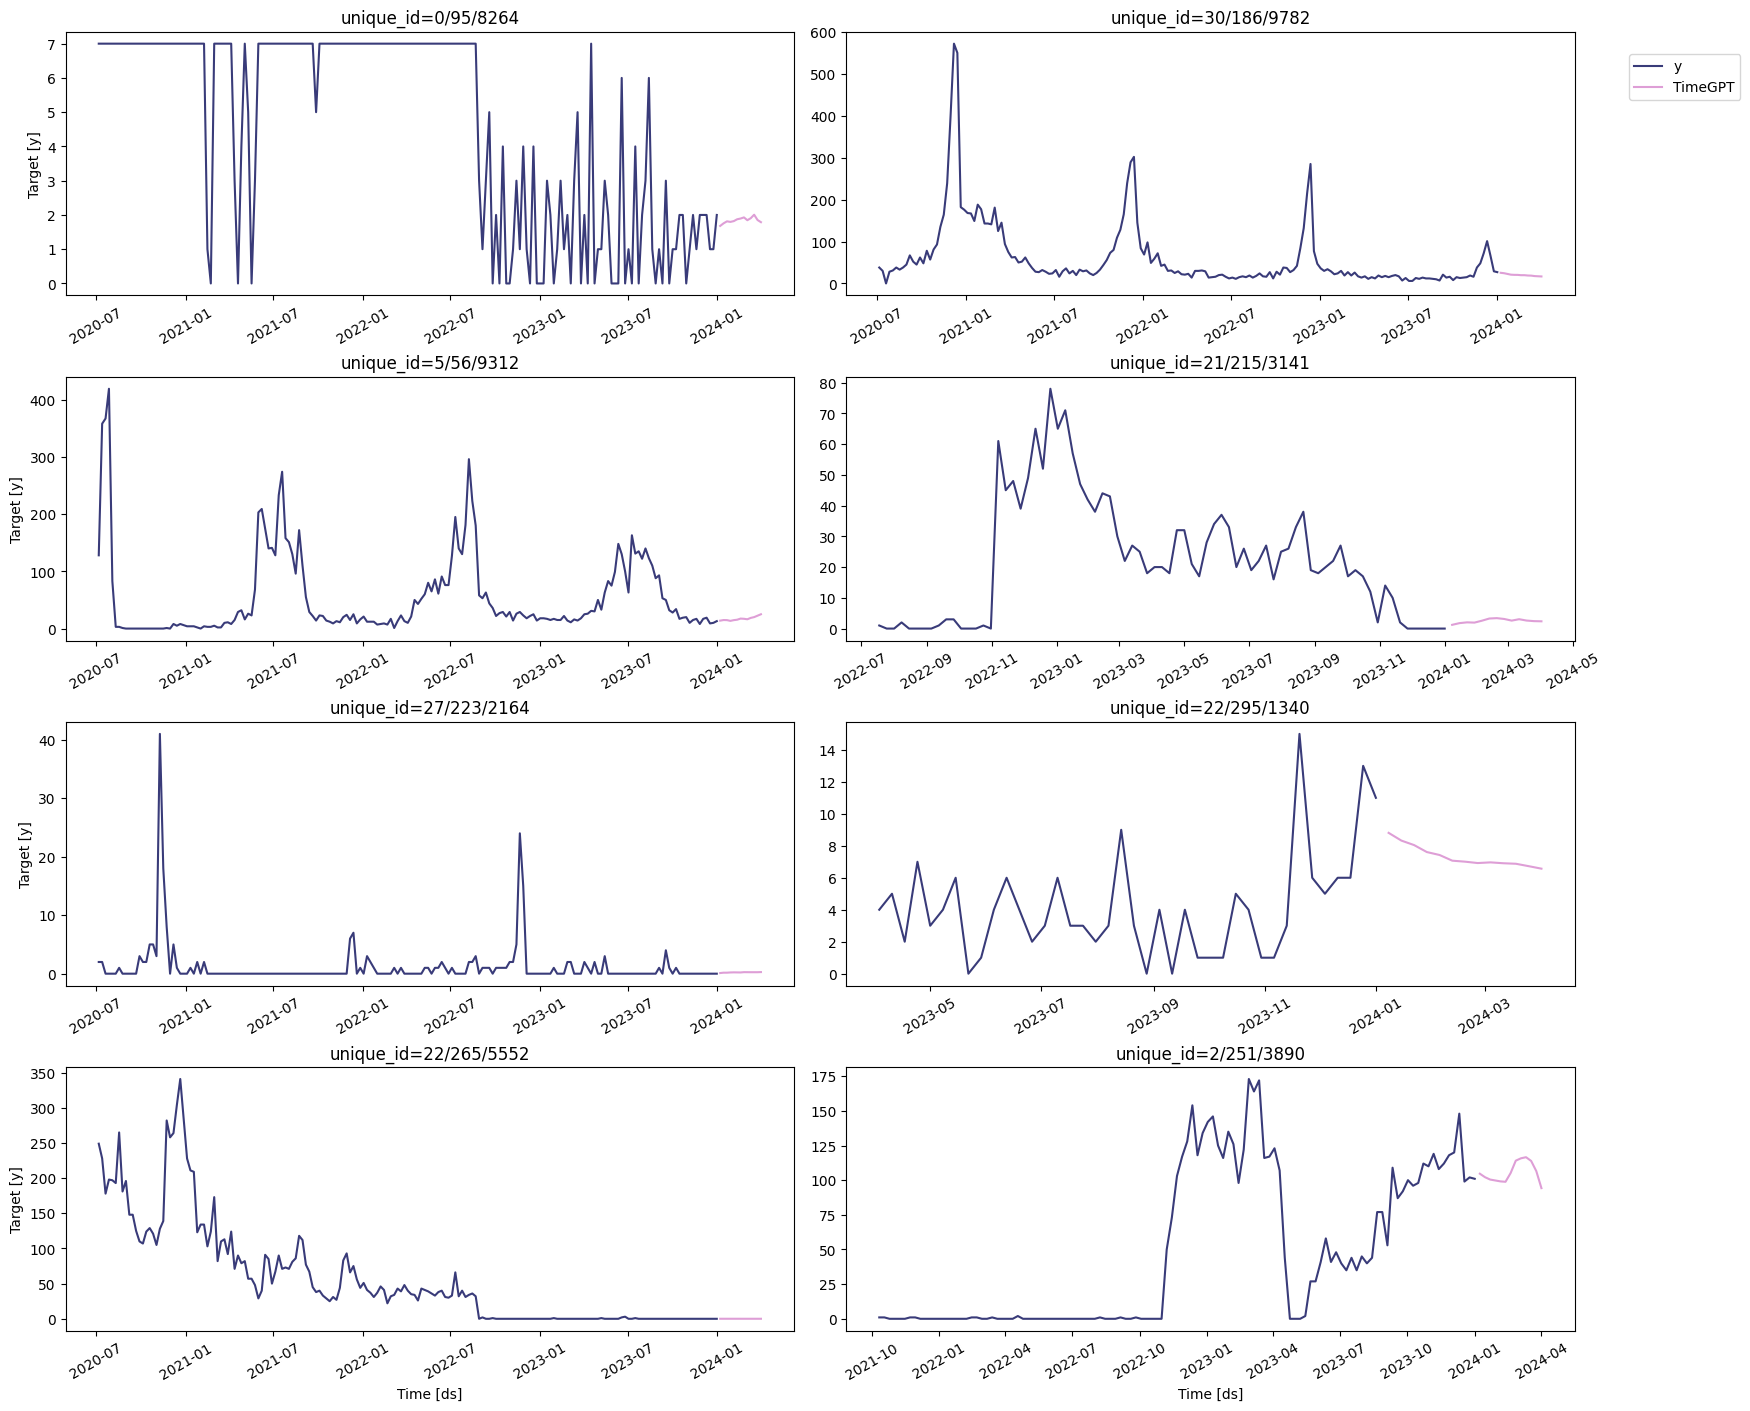

In [5]:
# Visualize TimeGPT Forecast ----
nixtla_client.plot(train_df, fc)

In [6]:
# Evaluate TimeGPT & Top 5 Competition Solutions ----
timegpt_score = vn1_competition_evaluation(test_df, fc, "TimeGPT")
timegpt_score 

np.float64(0.4651)

In [9]:
import timesfm
tfm = timesfm.TimesFm(
      hparams=timesfm.TimesFmHparams(
          backend="gpu",
          context_len=128,
          input_patch_len=32,
          per_core_batch_size=128,
          horizon_len=13,
      ),
      checkpoint=timesfm.TimesFmCheckpoint(
          huggingface_repo_id="google/timesfm-1.0-200m-pytorch"),
  )

Fetching 3 files: 100%|████████████████████████████████████████████████████████████████| 3/3 [00:00<00:00, 28149.69it/s]
INFO:root:Loading checkpoint from /home/semon/.cache/huggingface/hub/models--google--timesfm-1.0-200m-pytorch/snapshots/0581e2c56cb06feb51cfd98fc2b4005b74f7187b/torch_model.ckpt
INFO:root:Sending checkpoint to device cuda:0


In [13]:
import time
train_df['ds'] = pd.to_datetime(train_df['ds'])
start = time.time()
timesfm_df = tfm.forecast_on_df(
    inputs=train_df,
    freq='W',
    value_name='y',
    num_jobs=-1,
)
timesfm_duration = time.time() - start
print("TimesFM inference duration (seconds):", timesfm_duration)

INFO:root:Preprocessing dataframe.


Processing dataframe with multiple processes.
Finished preprocessing dataframe.


INFO:root:Finished creating output dataframe.


Finished forecasting.
TimesFM inference duration (seconds): 6.893909931182861


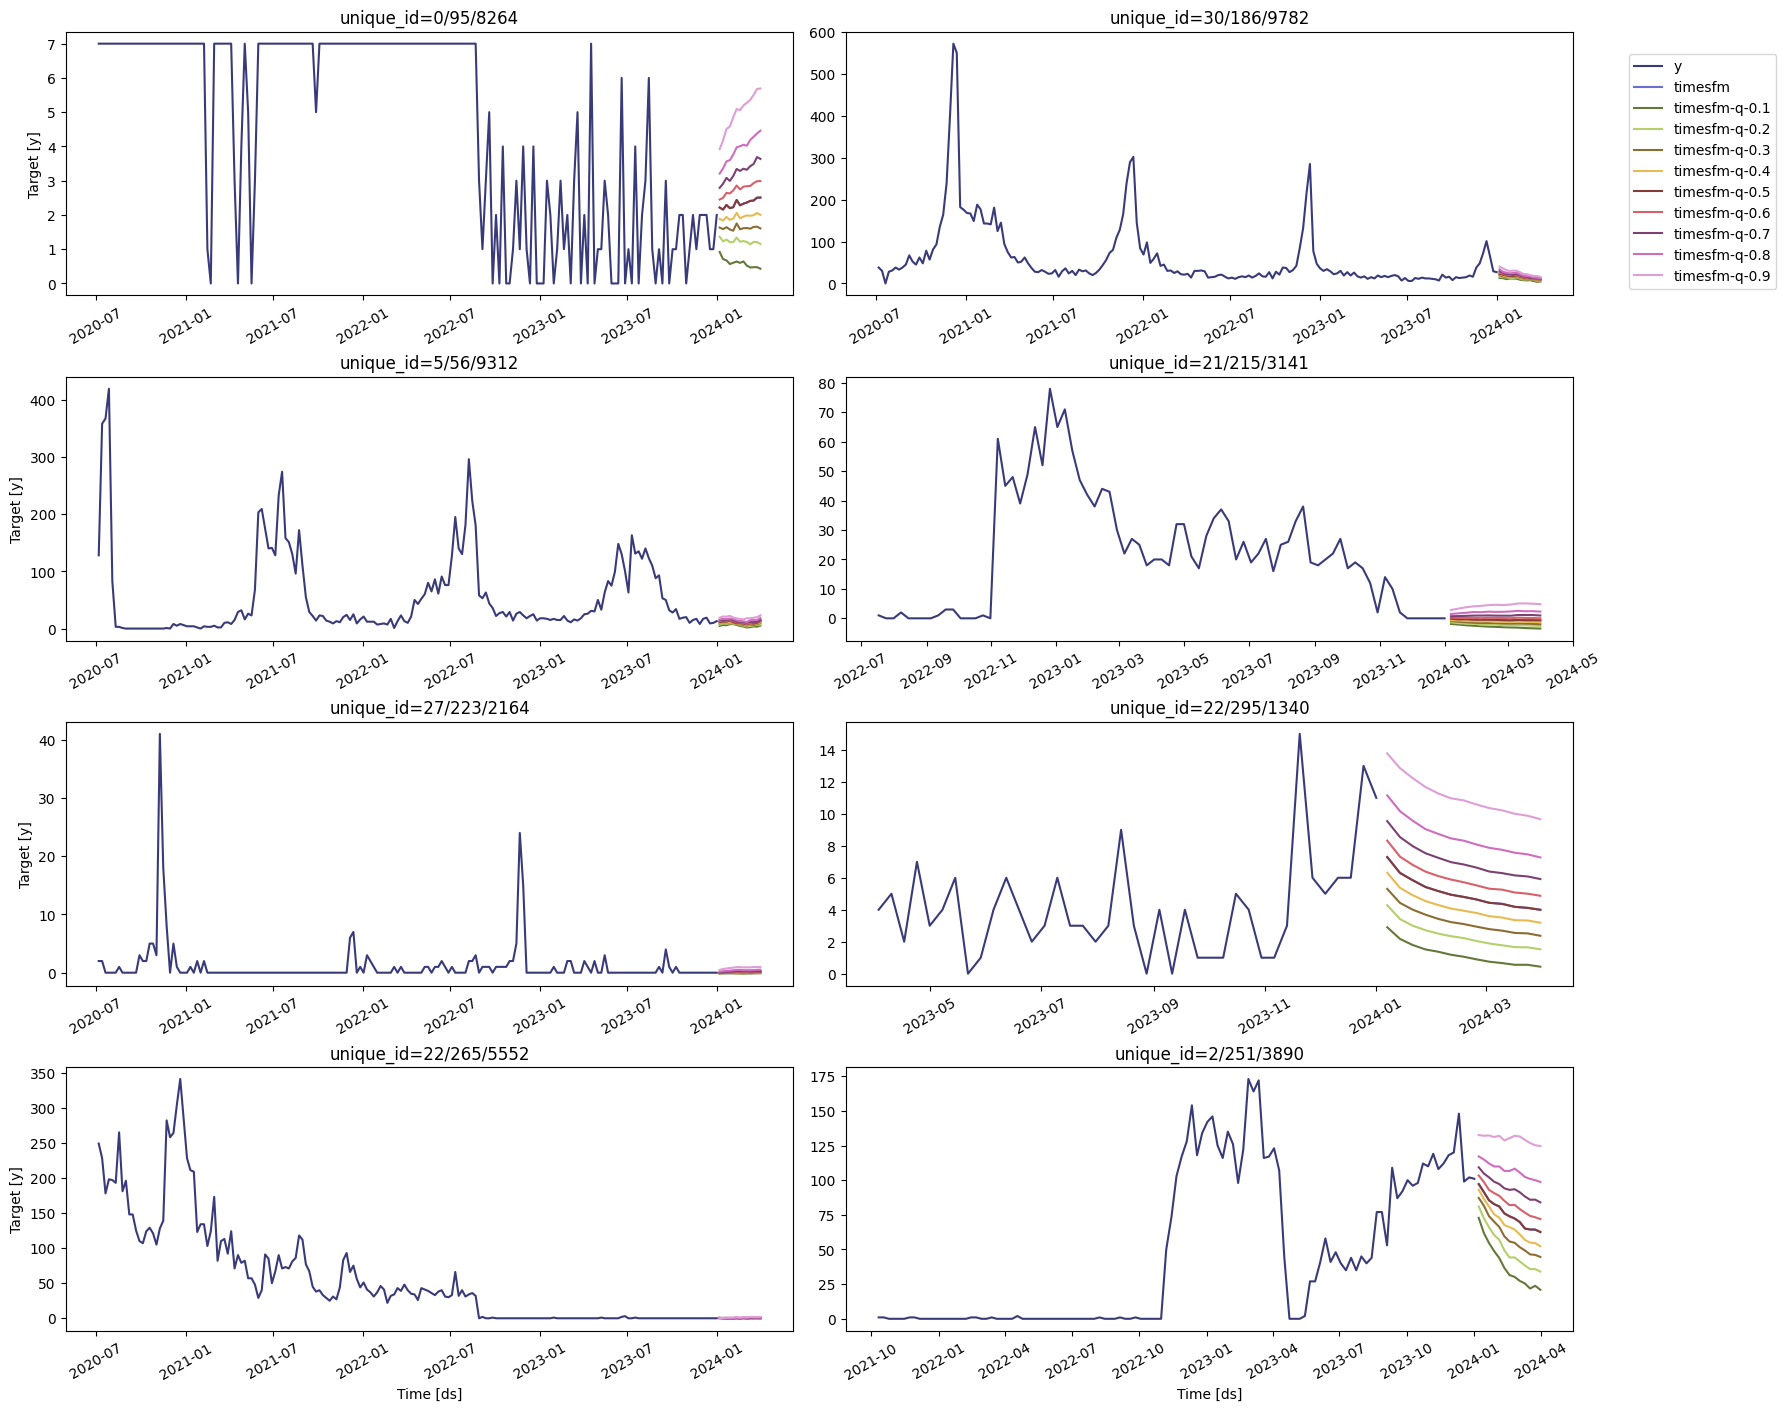

In [14]:
# Visualize TimeGPT Forecast ----
nixtla_client.plot(train_df, timesfm_df)

In [16]:
timesfm_df

,unique_id,ds,timesfm,timesfm-q-0.1,timesfm-q-0.2,timesfm-q-0.3,timesfm-q-0.4,timesfm-q-0.5,timesfm-q-0.6,timesfm-q-0.7,timesfm-q-0.8,timesfm-q-0.9
0,0/1/10705,2024-01-07,3.466080,1.161849,1.927189,2.434710,2.910192,3.466080,3.960686,4.641630,5.450599,6.844630
1,0/1/10705,2024-01-14,2.739833,0.523557,1.272791,1.776776,2.233940,2.739833,3.291778,3.994216,4.837222,6.307777
2,0/1/10705,2024-01-21,2.399277,0.235206,0.991544,1.528797,1.957982,2.399277,2.934406,3.663629,4.504704,6.032386
3,0/1/10705,2024-01-28,2.424110,0.257454,1.040468,1.520778,1.946873,2.424110,2.937617,3.602741,4.534106,6.003431
4,0/1/10705,2024-02-04,2.525429,0.370414,1.096184,1.566404,2.033061,2.525429,3.126011,3.766700,4.720530,6.242961
...,...,...,...,...,...,...,...,...,...,...,...,...
195684,9/82/9950,2024-03-03,0.000370,-0.006118,-0.001340,-0.001143,-0.001514,0.000370,0.002383,0.001772,0.004473,0.019698
195685,9/82/9950,2024-03-10,-0.000027,-0.007012,-0.005501,-0.001352,-0.001830,-0.000027,0.001635,0.000912,0.004480,0.017820
195686,9/82/9950,2024-03-17,0.001140,-0.003374,-0.001791,-0.000412,0.002568,0.001140,0.002225,0.002806,0.007221,0.020292
195687,9/82/9950,2024-03-24,-0.000102,-0.003299,-0.002931,-0.001137,0.001118,-0.000102,0.002185,0.003414,0.006981,0.020073


In [17]:
timesfm_df['ds'] = pd.to_datetime(timesfm_df['ds'])
timesfm_df['ds'] = timesfm_df['ds'] + pd.DateOffset(days=1)

In [18]:
timesfm_df

,unique_id,ds,timesfm,timesfm-q-0.1,timesfm-q-0.2,timesfm-q-0.3,timesfm-q-0.4,timesfm-q-0.5,timesfm-q-0.6,timesfm-q-0.7,timesfm-q-0.8,timesfm-q-0.9
0,0/1/10705,2024-01-08,3.466080,1.161849,1.927189,2.434710,2.910192,3.466080,3.960686,4.641630,5.450599,6.844630
1,0/1/10705,2024-01-15,2.739833,0.523557,1.272791,1.776776,2.233940,2.739833,3.291778,3.994216,4.837222,6.307777
2,0/1/10705,2024-01-22,2.399277,0.235206,0.991544,1.528797,1.957982,2.399277,2.934406,3.663629,4.504704,6.032386
3,0/1/10705,2024-01-29,2.424110,0.257454,1.040468,1.520778,1.946873,2.424110,2.937617,3.602741,4.534106,6.003431
4,0/1/10705,2024-02-05,2.525429,0.370414,1.096184,1.566404,2.033061,2.525429,3.126011,3.766700,4.720530,6.242961
...,...,...,...,...,...,...,...,...,...,...,...,...
195684,9/82/9950,2024-03-04,0.000370,-0.006118,-0.001340,-0.001143,-0.001514,0.000370,0.002383,0.001772,0.004473,0.019698
195685,9/82/9950,2024-03-11,-0.000027,-0.007012,-0.005501,-0.001352,-0.001830,-0.000027,0.001635,0.000912,0.004480,0.017820
195686,9/82/9950,2024-03-18,0.001140,-0.003374,-0.001791,-0.000412,0.002568,0.001140,0.002225,0.002806,0.007221,0.020292
195687,9/82/9950,2024-03-25,-0.000102,-0.003299,-0.002931,-0.001137,0.001118,-0.000102,0.002185,0.003414,0.006981,0.020073


In [20]:
timesfm_score = vn1_competition_evaluation(test_df, timesfm_df, "timesfm")
timesfm_score

np.float64(0.57)